---
Q2. List out top 2 and bottom 2 prominent pollutants for each state of southern India. 
(Consider data post covid: 2022 onwards)
---

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv('day-wise-state-wise-air-quality-index-aqi-of-major-cities-and-towns-in-india.csv')

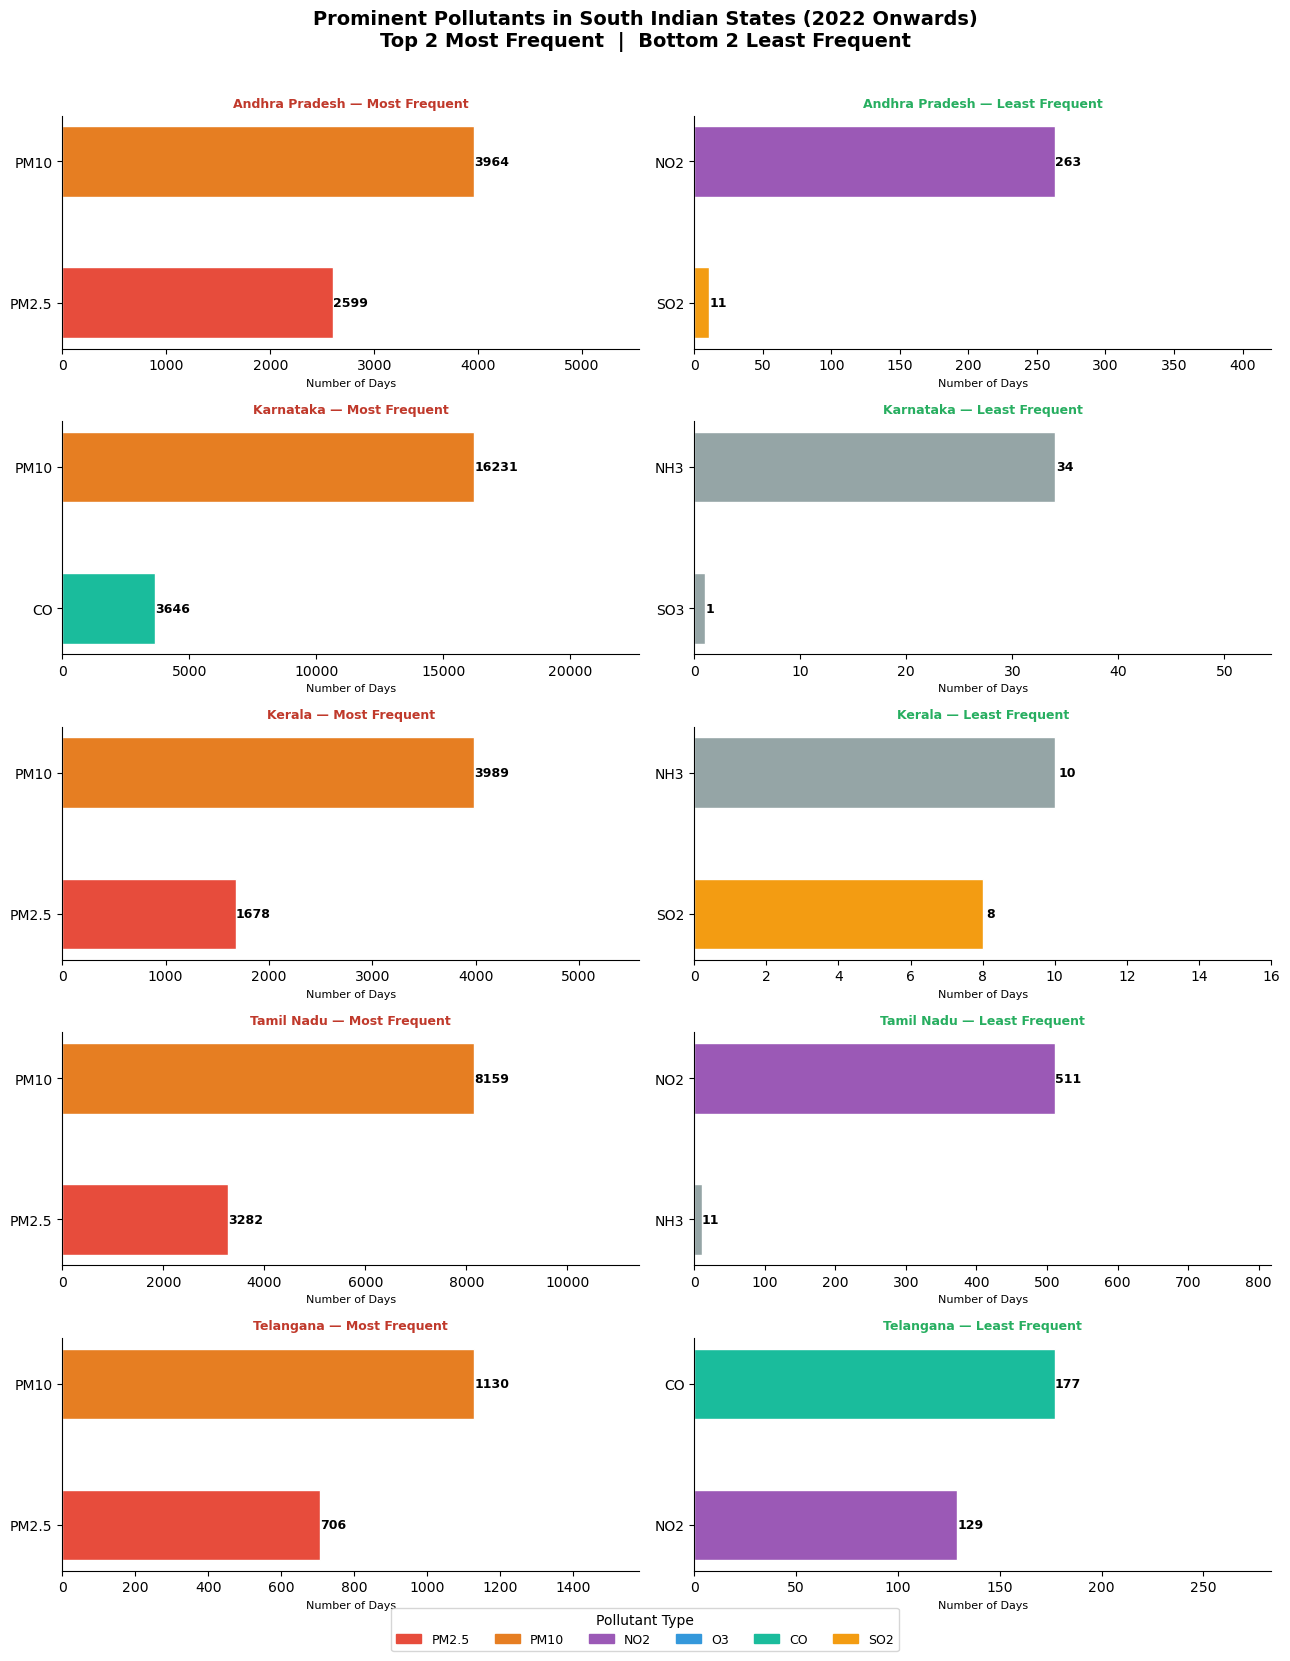

In [41]:

top_2_list    = []
bottom_2_list = []

for state in res['state'].unique():
    subset = res[res['state'] == state].sort_values('frequency', ascending=False)
    top_2_list.append(subset.head(2))
    bottom_2_list.append(subset.tail(2))

top_2_data    = pd.concat(top_2_list).reset_index(drop=True)
bottom_2_data = pd.concat(bottom_2_list).reset_index(drop=True)

# ─── Define colors for each pollutant ────────────────────────────────
pollutant_color = {
    'PM2.5' : '#e74c3c',   # red
    'PM10'  : '#e67e22',   # orange
    'NO2'   : '#9b59b6',   # purple
    'O3'    : '#3498db',   # blue
    'CO'    : '#1abc9c',   # teal
    'SO2'   : '#f39c12',   # yellow
}

def get_color(pollutant):
    pollutant = pollutant.strip()
    return pollutant_color.get(pollutant, '#95a5a6')  # grey if not found

# ───  Set up the figure — 5 states, each with 2 small charts ──────────
states = ['Andhra Pradesh', 'Karnataka', 'Kerala', 'Tamil Nadu', 'Telangana']

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(13, 16))

fig.suptitle(
    'Prominent Pollutants in South Indian States (2022 Onwards)\nTop 2 Most Frequent  |  Bottom 2 Least Frequent',
    fontsize=14, fontweight='bold', y=1.01
)

# ───  Draw one row per state ──────────────────────────────────────────
for row, state in enumerate(states):

    # --- Left chart: Top 2 pollutants ---
    top_data = top_2_data[top_2_data['state'] == state] \
               .sort_values('frequency', ascending=True)  # ascending for barh

    bar_colors = [get_color(p) for p in top_data['prominent_pollutants']]

    axes[row][0].barh(
        top_data['prominent_pollutants'],
        top_data['frequency'],
        color=bar_colors,
        edgecolor='white',
        height=0.5
    )

    # Add value labels
    for i, val in enumerate(top_data['frequency']):
        axes[row][0].text(
            val + 0.3, i,
            str(int(val)),
            va='center', fontsize=9, fontweight='bold'
        )

    axes[row][0].set_title(f'{state} — Most Frequent',
                            fontsize=9, fontweight='bold', color='#c0392b')
    axes[row][0].set_xlabel('Number of Days', fontsize=8)
    axes[row][0].set_xlim(0, top_data['frequency'].max() * 1.4)
    axes[row][0].spines[['top', 'right']].set_visible(False)

    # --- Right chart: Bottom 2 pollutants ---
    bot_data = bottom_2_data[bottom_2_data['state'] == state] \
               .sort_values('frequency', ascending=True)

    bar_colors_b = [get_color(p) for p in bot_data['prominent_pollutants']]

    axes[row][1].barh(
        bot_data['prominent_pollutants'],
        bot_data['frequency'],
        color=bar_colors_b,
        edgecolor='white',
        height=0.5
    )

    # Add value labels
    for i, val in enumerate(bot_data['frequency']):
        axes[row][1].text(
            val + 0.1, i,
            str(int(val)),
            va='center', fontsize=9, fontweight='bold'
        )

    axes[row][1].set_title(f'{state} — Least Frequent',
                            fontsize=9, fontweight='bold', color='#27ae60')
    axes[row][1].set_xlabel('Number of Days', fontsize=8)
    axes[row][1].set_xlim(0, max(bot_data['frequency'].max() * 1.6, 5))
    axes[row][1].spines[['top', 'right']].set_visible(False)

# ─── Add a shared legend at the bottom ───────────────────────────────
from matplotlib.patches import Patch

legend_items = [Patch(color=color, label=pollutant)
                for pollutant, color in pollutant_color.items()]

fig.legend(
    handles=legend_items,
    loc='lower center',
    ncol=6,
    fontsize=9,
    title='Pollutant Type',
    bbox_to_anchor=(0.5, -0.02),
    frameon=True
)

plt.tight_layout()
plt.show()

In [42]:
#average AQI in each southern state
avg_aqi=df.groupby('state')['aqi_value'].mean().reset_index(name='avg_aqi')
avg_aqi

,state,avg_aqi
0,Andhra Pradesh,77.034296
1,Karnataka,63.701395
2,Kerala,67.443898
3,Tamil Nadu,66.329317
4,Telangana,82.235776


#### Key Insights :

South India does not have a uniform air quality problem - it has 5 distinct pollution profiles requiring 5 distinct products and marketing strategies. A one-size-fits-all air purifier will underserve every market. AirPure's competitive advantage lies in city-specific product configurations driven by this localised pollution data.